# Análisis Completo de Datos Históricos - PCI Scores
## Historical Pavement Condition Index (Índice de Condición del Pavimento Histórico)
**Fecha:** 27/05/2026  
**Archivo:** Streets_Data_-Historical_Pavement_Condition_Index_(PCI)_Scores_20260527.csv  
**Nota:** Este es el dataset histórico con datos de muchos años

## 1. Importar librerías necesarias

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurar estilos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 2. Cargar los datos históricos

In [25]:
# Cargar el archivo CSV histórico
# NOTA: Este archivo es más grande (~85MB), el parámetro dtype ayuda a optimizar la carga
file_path = r'./PCI-histo.csv'

print('Cargando archivo histórico (esto puede tomar un momento)...')
df_hist = pd.read_csv(file_path)

print('✓ Archivo cargado exitosamente')
print(f'Forma del dataset: {df_hist.shape}')
print(f'Tamaño en memoria: {df_hist.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')

Cargando archivo histórico (esto puede tomar un momento)...
✓ Archivo cargado exitosamente
Forma del dataset: (307133, 15)
Tamaño en memoria: 190.06 MB


In [45]:
df_hist.head()

,CNN,Street_Name,From_Street,To_Street,PCI_Score,PCI_Change_Date,Treatment_or_Survey,Street_Accepted_For_Maintenance,Functional_Class,X,Y,Latitude,Longitude,Line,Point,Year,Month
0,11007000,Rice St,San Jose Ave,De Long St,80,2012-03-13 13:35:18,Survey,Yes,Residential,5.995097e+06,2.086669e+06,37.709315,-122.458715,"LINESTRING (-122.458241194555 37.708999302049,...",NaN,2012.0,3.0
1,11760000,Seneca Ave,Bannock St,Cayuga Ave,62,2016-06-07 07:45:15,Treatment,Yes,Residential,5.999945e+06,2.090223e+06,37.719351,-122.442214,"LINESTRING (-122.441876765577 37.719081159747,...",NaN,2016.0,6.0
2,8785000,MARTHA AVE,END,BADEN ST,100,2008-10-29 13:59:26,Survey,No,NaN,6.000867e+06,2.095502e+06,37.733899,-122.439405,"LINESTRING (-122.43905085277 37.733770492344, ...",NaN,2008.0,10.0
3,7482000,Jennings St,Armstrong Ave,Bancroft Ave,76,2016-10-03 12:56:35,Survey,Yes,Residential,6.014899e+06,2.091922e+06,37.724856,-122.390644,"LINESTRING (-122.390362708159 37.725167205981,...",NaN,2016.0,10.0
4,7037000,HOWARD ST,HAWTHORNE ST,03RD ST,46,1996-08-03 00:00:00,Survey,Yes,Arterial,6.012664e+06,2.114040e+06,37.785465,-122.399919,"LINESTRING (-122.399369534008 37.785899247699,...",NaN,1996.0,8.0


## 3. Información General del Dataset Histórico

In [26]:
print('='*80)
print('INFORMACIÓN GENERAL DEL DATASET HISTÓRICO')
print('='*80)
print(f'\nNúmero total de filas (registros): {df_hist.shape[0]:,}')
print(f'Número total de columnas: {df_hist.shape[1]}')
print(f'Tamaño en memoria: {df_hist.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')
print(f'\nMemoria por columna:')
for col, mem in df_hist.memory_usage(deep=True).items():
    print(f'  {col:30s}: {mem / 1024 / 1024:6.2f} MB')

INFORMACIÓN GENERAL DEL DATASET HISTÓRICO

Número total de filas (registros): 307,133
Número total de columnas: 15
Tamaño en memoria: 190.06 MB

Memoria por columna:
  Index                         :   0.00 MB
  CNN                           :   2.34 MB
  Street_Name                   :  17.40 MB
  From_Street                   :  17.43 MB
  To_Street                     :  17.42 MB
  PCI_Score                     :   2.34 MB
  PCI_Change_Date               :  21.09 MB
  Treatment_or_Survey           :  16.21 MB
  Street_Accepted_For_Maintenance:  15.22 MB
  Functional_Class              :  16.90 MB
  X                             :   2.34 MB
  Y                             :   2.34 MB
  Latitude                      :   2.34 MB
  Longitude                     :   2.34 MB
  Line                          :  44.59 MB
  Point                         :   9.75 MB


## 4. Estructura de Datos - Columnas y Tipos

In [27]:
print('\n' + '='*80)
print('COLUMNAS DEL DATASET HISTÓRICO')
print('='*80)

for i, col in enumerate(df_hist.columns, 1):
    print(f'{i:2d}. {col}')

print('\n' + '='*80)
print('TIPOS DE DATOS')
print('='*80)
print(df_hist.dtypes)


COLUMNAS DEL DATASET HISTÓRICO
 1. CNN
 2. Street_Name
 3. From_Street
 4. To_Street
 5. PCI_Score
 6. PCI_Change_Date
 7. Treatment_or_Survey
 8. Street_Accepted_For_Maintenance
 9. Functional_Class
10. X
11. Y
12. Latitude
13. Longitude
14. Line
15. Point

TIPOS DE DATOS
CNN                                  int64
Street_Name                         object
From_Street                         object
To_Street                           object
PCI_Score                            int64
PCI_Change_Date                     object
Treatment_or_Survey                 object
Street_Accepted_For_Maintenance     object
Functional_Class                    object
X                                  float64
Y                                  float64
Latitude                           float64
Longitude                          float64
Line                                object
Point                               object
dtype: object


## 5. Análisis de Valores Nulos

In [28]:
print('\n' + '='*80)
print('ANÁLISIS DE VALORES NULOS')
print('='*80)

# Crear tabla de valores nulos
null_analysis = pd.DataFrame({
    'Columna': df_hist.columns,
    'Valores Nulos': df_hist.isnull().sum().values,
    'Porcentaje (%)': (df_hist.isnull().sum().values / len(df_hist) * 100).round(2),
    'Valores Válidos': df_hist.notna().sum().values
})

print(null_analysis.to_string(index=False))

print(f'\n\nTOTAL de valores nulos en el dataset: {df_hist.isnull().sum().sum():,}')
print(f'Porcentaje total: {(df_hist.isnull().sum().sum() / (df_hist.shape[0] * df_hist.shape[1]) * 100):.2f}%')


ANÁLISIS DE VALORES NULOS
                        Columna  Valores Nulos  Porcentaje (%)  Valores Válidos
                            CNN              0            0.00           307133
                    Street_Name              0            0.00           307133
                    From_Street              1            0.00           307132
                      To_Street              0            0.00           307133
                      PCI_Score              0            0.00           307133
                PCI_Change_Date             70            0.02           307063
            Treatment_or_Survey              0            0.00           307133
Street_Accepted_For_Maintenance              0            0.00           307133
               Functional_Class          14117            4.60           293016
                              X              0            0.00           307133
                              Y              0            0.00           307133
             

## 6. Visualización de Valores Nulos

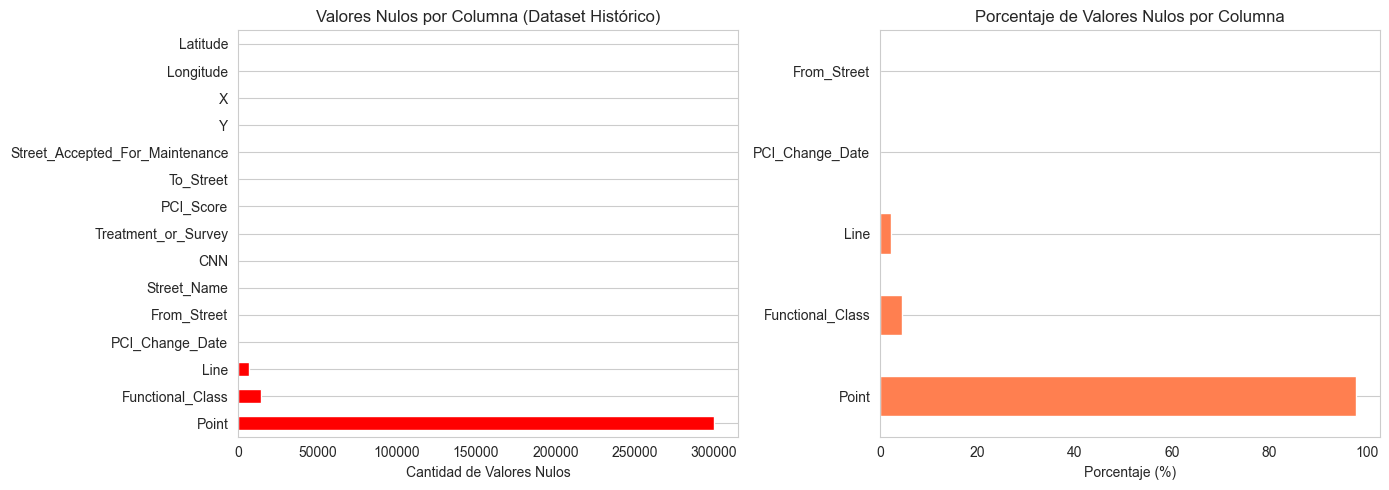

In [29]:
# Gráfico de valores nulos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cantidad de nulos por columna
null_counts = df_hist.isnull().sum()
null_counts_sorted = null_counts.sort_values(ascending=False)
colors = ['red' if x > 0 else 'green' for x in null_counts_sorted.values]
null_counts_sorted.plot(kind='barh', ax=ax1, color=colors)
ax1.set_xlabel('Cantidad de Valores Nulos')
ax1.set_title('Valores Nulos por Columna (Dataset Histórico)')
ax1.grid(axis='x')

# Gráfico 2: Porcentaje de nulos
null_percentage = (df_hist.isnull().sum() / len(df_hist) * 100).sort_values(ascending=False)
null_percentage_sorted = null_percentage[null_percentage > 0]
null_percentage_sorted.plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Porcentaje (%)')
ax2.set_title('Porcentaje de Valores Nulos por Columna')
ax2.grid(axis='x')

plt.tight_layout()
plt.show()

## 7. Análisis Estadístico - PCI_Score Histórico

In [30]:
print('\n' + '='*80)
print('ANÁLISIS ESTADÍSTICO - PCI_SCORE (Histórico)')
print('='*80)

pci_stats = {
    'Mínimo': df_hist['PCI_Score'].min(),
    'Máximo': df_hist['PCI_Score'].max(),
    'Media': df_hist['PCI_Score'].mean(),
    'Mediana': df_hist['PCI_Score'].median(),
    'Desv. Estándar': df_hist['PCI_Score'].std(),
    'Varianza': df_hist['PCI_Score'].var(),
    'Q1 (25%)': df_hist['PCI_Score'].quantile(0.25),
    'Q3 (75%)': df_hist['PCI_Score'].quantile(0.75),
    'Rango Intercuartil': df_hist['PCI_Score'].quantile(0.75) - df_hist['PCI_Score'].quantile(0.25)
}

for key, value in pci_stats.items():
    print(f'{key:25s}: {value:10.2f}')

print('\n' + df_hist['PCI_Score'].describe().to_string())


ANÁLISIS ESTADÍSTICO - PCI_SCORE (Histórico)
Mínimo                   :       0.00
Máximo                   :     100.00
Media                    :      73.05
Mediana                  :      75.00
Desv. Estándar           :      19.48
Varianza                 :     379.30
Q1 (25%)                 :      60.00
Q3 (75%)                 :      87.00
Rango Intercuartil       :      27.00

count    307133.000000
mean         73.054185
std          19.475516
min           0.000000
25%          60.000000
50%          75.000000
75%          87.000000
max         100.000000


## 8. Distribución de PCI_Score Histórico

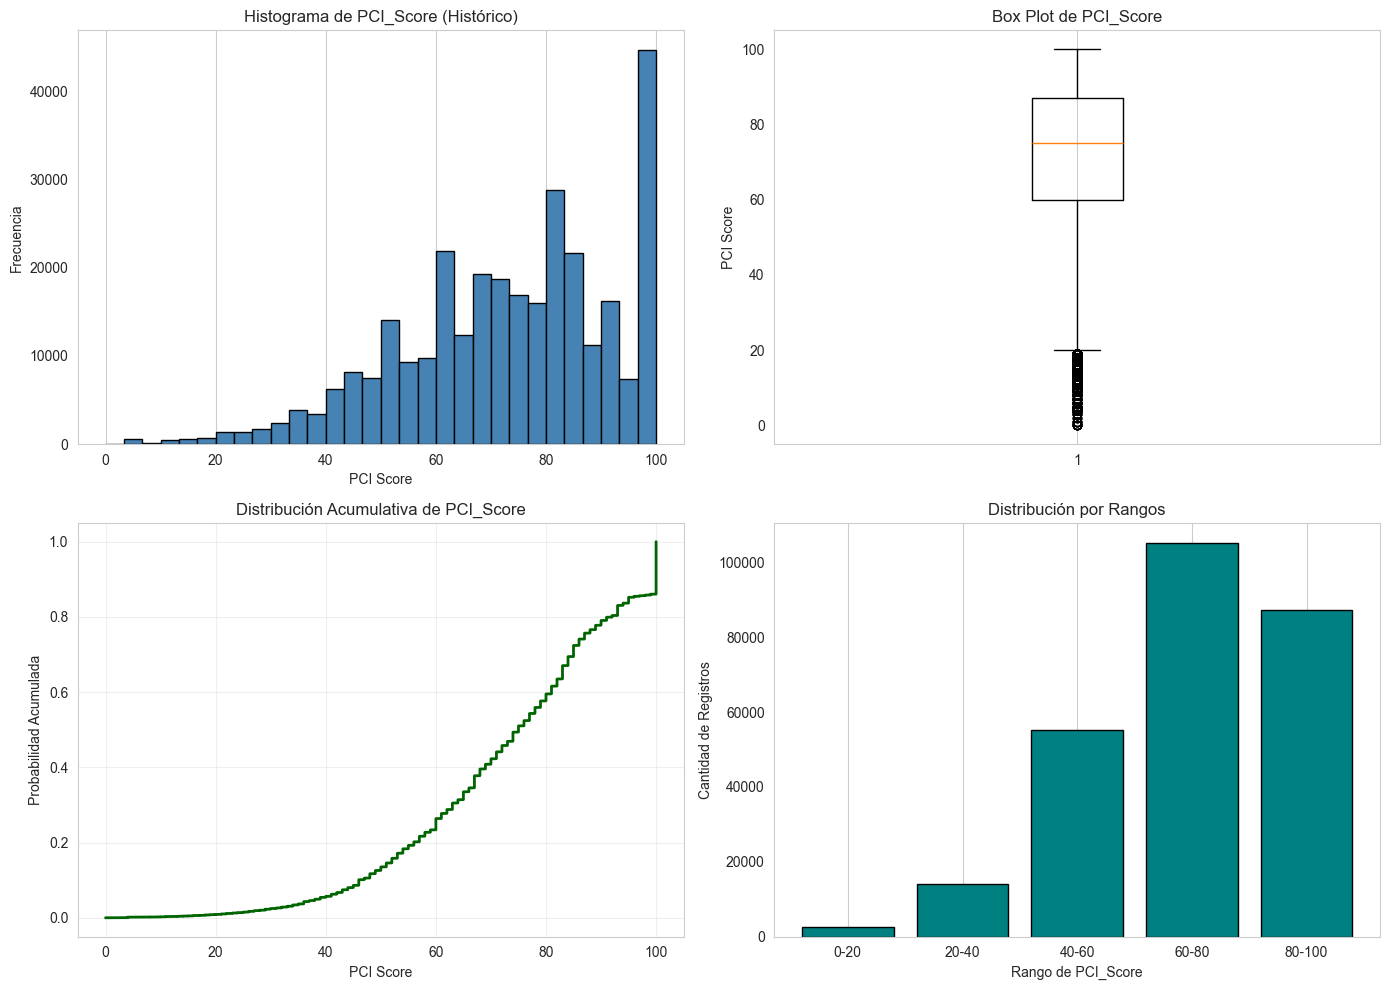


Distribución por rangos:
PCI_Score
0-20        2500
20-40      14135
40-60      55114
60-80     105277
80-100     87190
Name: count, dtype: int64

Porcentajes:
PCI_Score
0-20       0.81
20-40      4.60
40-60     17.94
60-80     34.28
80-100    28.39
Name: count, dtype: float64


In [31]:
# Histograma y análisis de distribución
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
axes[0, 0].hist(df_hist['PCI_Score'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('PCI Score')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Histograma de PCI_Score (Histórico)')
axes[0, 0].grid(axis='y')

# Box plot
axes[0, 1].boxplot(df_hist['PCI_Score'], vert=True)
axes[0, 1].set_ylabel('PCI Score')
axes[0, 1].set_title('Box Plot de PCI_Score')
axes[0, 1].grid(axis='y')

# Distribución acumulativa
sorted_pci = np.sort(df_hist['PCI_Score'])
cumulative = np.arange(1, len(sorted_pci) + 1) / len(sorted_pci)
axes[1, 0].plot(sorted_pci, cumulative, linewidth=2, color='darkgreen')
axes[1, 0].set_xlabel('PCI Score')
axes[1, 0].set_ylabel('Probabilidad Acumulada')
axes[1, 0].set_title('Distribución Acumulativa de PCI_Score')
axes[1, 0].grid(True, alpha=0.3)

# Conteo por rangos
ranges = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
binned = pd.cut(df_hist['PCI_Score'], bins=ranges, labels=labels, right=False)
binned_counts = binned.value_counts().sort_index()
axes[1, 1].bar(range(len(binned_counts)), binned_counts.values, color='teal', edgecolor='black')
axes[1, 1].set_xticks(range(len(binned_counts)))
axes[1, 1].set_xticklabels(binned_counts.index)
axes[1, 1].set_xlabel('Rango de PCI_Score')
axes[1, 1].set_ylabel('Cantidad de Registros')
axes[1, 1].set_title('Distribución por Rangos')
axes[1, 1].grid(axis='y')

plt.tight_layout()
plt.show()

print('\nDistribución por rangos:')
print(binned_counts)
print(f'\nPorcentajes:')
print((binned_counts / len(df_hist) * 100).round(2))

## 9. Análisis de Variables Categóricas

In [32]:
print('\n' + '='*80)
print('ANÁLISIS DE VARIABLES CATEGÓRICAS (Histórico)')
print('='*80)

# Treatment_or_Survey
print('\n1. TREATMENT_OR_SURVEY (Tipo de Actividad):')
print('-' * 60)
treatment_counts = df_hist['Treatment_or_Survey'].value_counts()
treatment_pct = (df_hist['Treatment_or_Survey'].value_counts(normalize=True) * 100).round(2)
treatment_summary = pd.DataFrame({
    'Valor': treatment_counts.index,
    'Cantidad': treatment_counts.values,
    'Porcentaje': treatment_pct.values
})
print(treatment_summary.to_string(index=False))

# Street_Accepted_For_Maintenance
print('\n2. STREET_ACCEPTED_FOR_MAINTENANCE (Aceptada para Mantenimiento):')
print('-' * 60)
maintenance_counts = df_hist['Street_Accepted_For_Maintenance'].value_counts(dropna=False)
maintenance_pct = (df_hist['Street_Accepted_For_Maintenance'].value_counts(normalize=True, dropna=False) * 100).round(2)
maintenance_summary = pd.DataFrame({
    'Valor': maintenance_counts.index,
    'Cantidad': maintenance_counts.values,
    'Porcentaje': maintenance_pct.values
})
print(maintenance_summary.to_string(index=False))

# Functional_Class
print('\n3. FUNCTIONAL_CLASS (Clasificación Funcional):')
print('-' * 60)
func_counts = df_hist['Functional_Class'].value_counts(dropna=False)
func_pct = (df_hist['Functional_Class'].value_counts(normalize=True, dropna=False) * 100).round(2)
func_summary = pd.DataFrame({
    'Valor': func_counts.index,
    'Cantidad': func_counts.values,
    'Porcentaje': func_pct.values
})
print(func_summary.to_string(index=False))


ANÁLISIS DE VARIABLES CATEGÓRICAS (Histórico)

1. TREATMENT_OR_SURVEY (Tipo de Actividad):
------------------------------------------------------------
    Valor  Cantidad  Porcentaje
   Survey    272185       88.62
Treatment     34948       11.38

2. STREET_ACCEPTED_FOR_MAINTENANCE (Aceptada para Mantenimiento):
------------------------------------------------------------
Valor  Cantidad  Porcentaje
  Yes    292569       95.26
   No     14564        4.74

3. FUNCTIONAL_CLASS (Clasificación Funcional):
------------------------------------------------------------
      Valor  Cantidad  Porcentaje
Residential    178844       58.23
   Arterial     81969       26.69
  Collector     32203       10.49
        NaN     14117        4.60


## 10. Visualización de Variables Categóricas

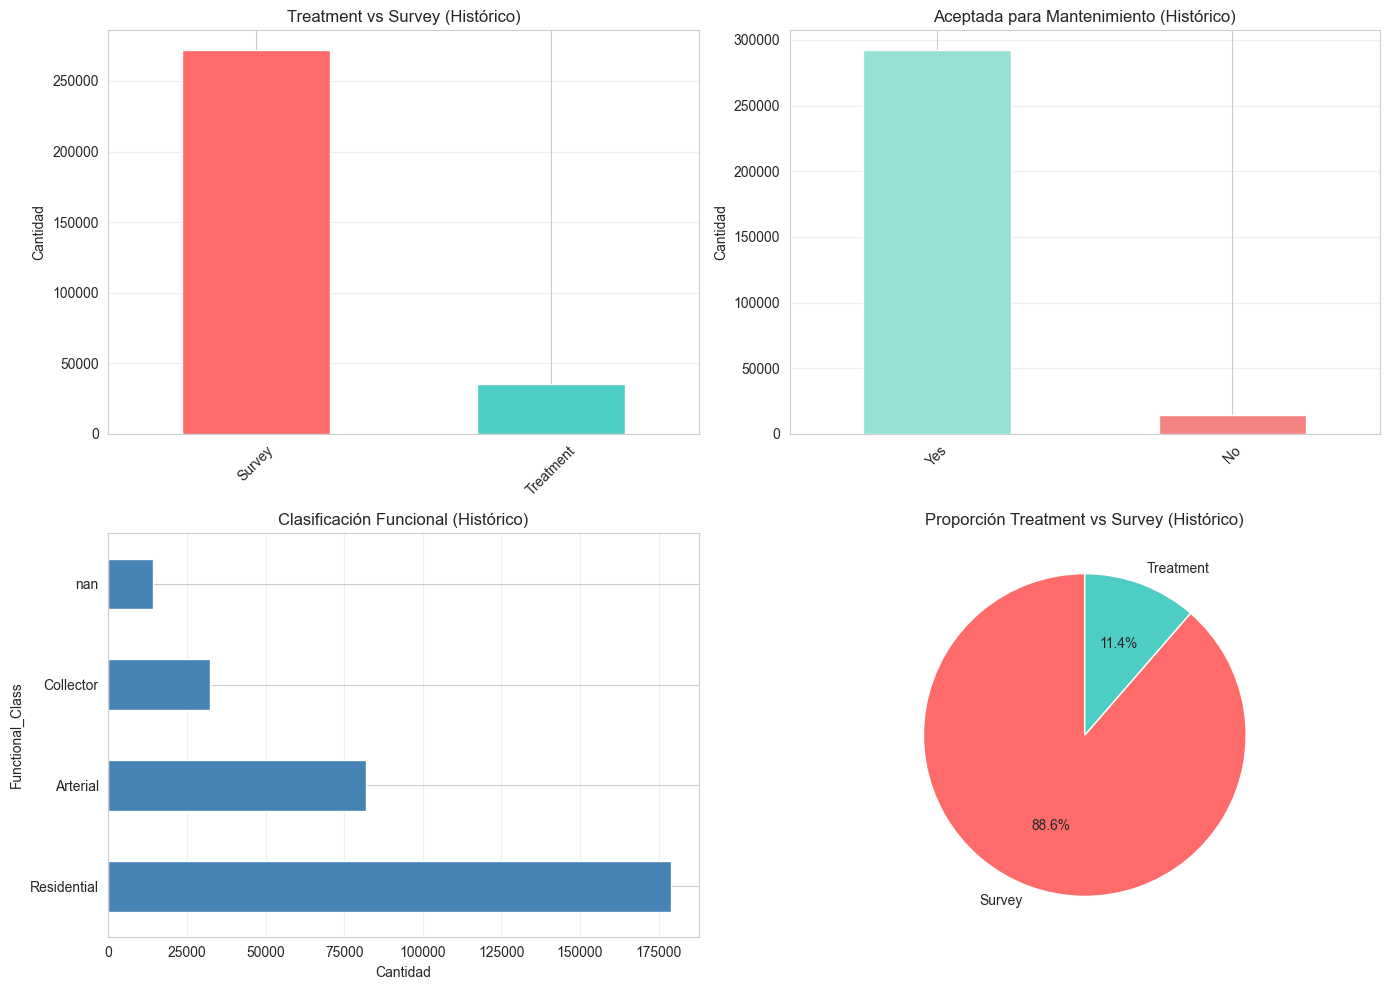

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Treatment or Survey
treatment_counts.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Treatment vs Survey (Histórico)')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Maintenance Accepted
maintenance_counts.plot(kind='bar', ax=axes[0, 1], color=['#95E1D3', '#F38181', '#CCCCCC'])
axes[0, 1].set_title('Aceptada para Mantenimiento (Histórico)')
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Functional Class
func_counts.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Clasificación Funcional (Histórico)')
axes[1, 0].set_xlabel('Cantidad')
axes[1, 0].grid(axis='x', alpha=0.3)

# Pie chart Treatment
colors_pie = ['#FF6B6B', '#4ECDC4']
axes[1, 1].pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%',
                colors=colors_pie, startangle=90)
axes[1, 1].set_title('Proporción Treatment vs Survey (Histórico)')

plt.tight_layout()
plt.show()


## 11. Análisis Temporal - La Clave del Dataset Histórico

In [34]:
# Convertir fecha (formato diferente en histórico)
print('Detectando formato de fecha...')
df_hist['PCI_Change_Date'] = pd.to_datetime(df_hist['PCI_Change_Date'], errors='coerce')
df_hist['Year'] = df_hist['PCI_Change_Date'].dt.year
df_hist['Month'] = df_hist['PCI_Change_Date'].dt.month

print('\n' + '='*80)
print('ANÁLISIS TEMPORAL - DATASET HISTÓRICO')
print('='*80)

print(f'\nRango de fechas:')
print(f'  Fecha mínima: {df_hist["PCI_Change_Date"].min()}')
print(f'  Fecha máxima: {df_hist["PCI_Change_Date"].max()}')
años_rango = (df_hist['PCI_Change_Date'].max() - df_hist['PCI_Change_Date'].min()).days / 365.25
print(f'  Período cubierto: {años_rango:.1f} años')

# Datos sin NaT
df_hist_valid_dates = df_hist[df_hist['Year'].notna()]

print(f'\nRegistros con fechas válidas: {len(df_hist_valid_dates):,} ({len(df_hist_valid_dates)/len(df_hist)*100:.2f}%)')
print(f'Registros con fechas inválidas: {df_hist["Year"].isna().sum():,}')

print('\nRegistros por año (histórico):')
yearly_counts = df_hist_valid_dates['Year'].value_counts().sort_index()
print(yearly_counts)

Detectando formato de fecha...

ANÁLISIS TEMPORAL - DATASET HISTÓRICO

Rango de fechas:
  Fecha mínima: 1947-11-01 00:00:00
  Fecha máxima: 2026-05-19 08:28:06
  Período cubierto: 78.5 años

Registros con fechas válidas: 307,063 (99.98%)
Registros con fechas inválidas: 70

Registros por año (histórico):
Year
1947.0        1
1948.0       21
1949.0       13
1950.0       15
1951.0       36
          ...  
2022.0    12987
2023.0    13841
2024.0    13549
2025.0    13184
2026.0      302
Name: count, Length: 80, dtype: int64


## 12. Gráficos Temporales Históricos

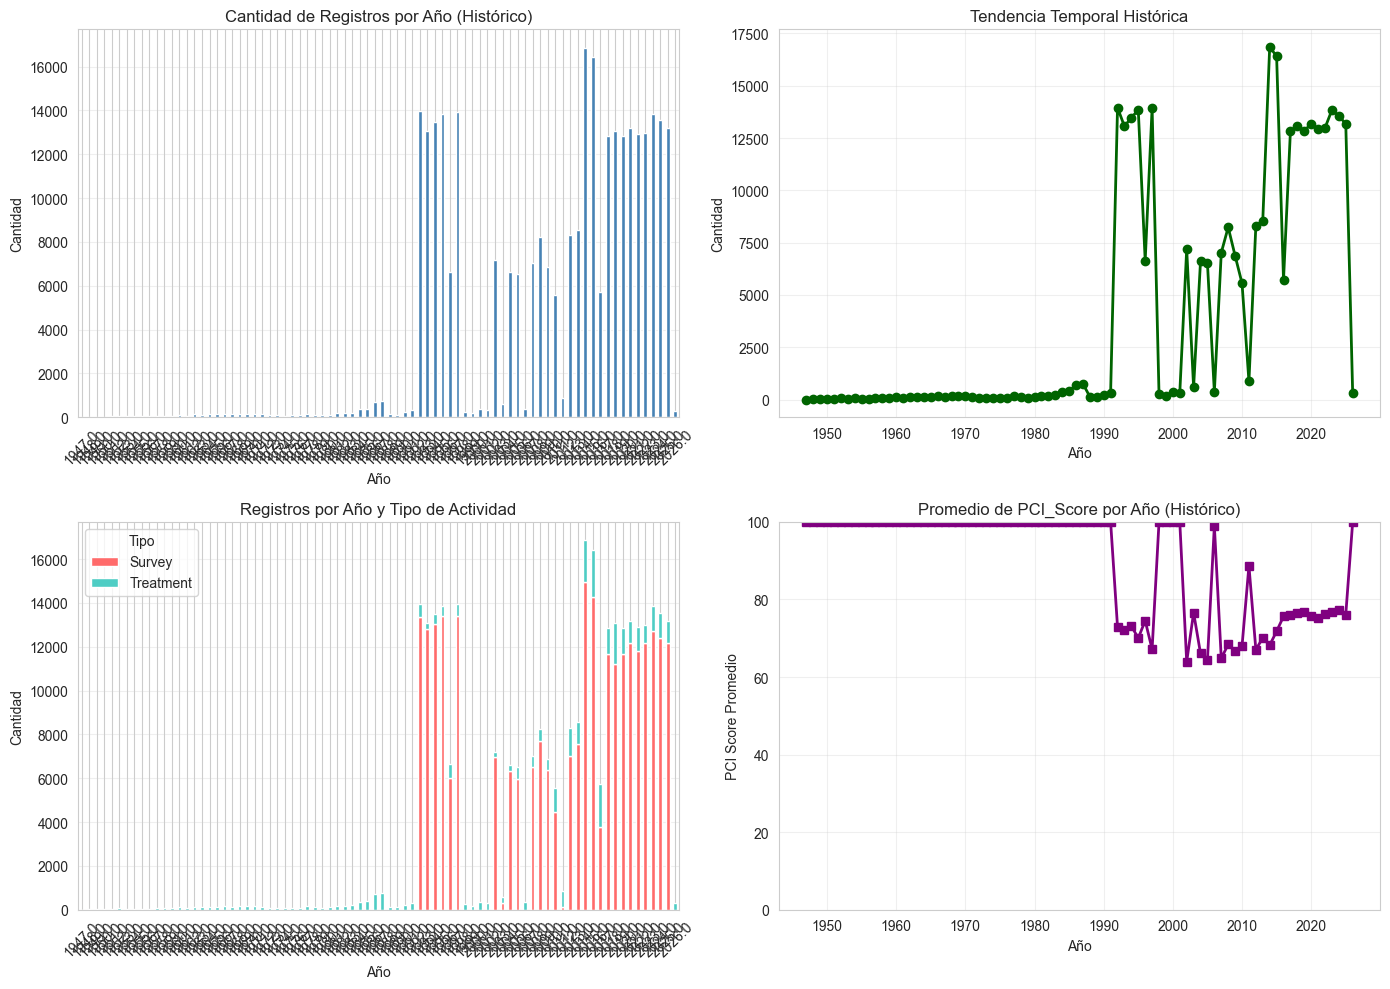

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Registros por año
yearly_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Cantidad de Registros por Año (Histórico)')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].set_xlabel('Año')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Línea temporal
yearly_counts.plot(kind='line', ax=axes[0, 1], marker='o', linewidth=2, color='darkgreen')
axes[0, 1].set_title('Tendencia Temporal Histórica')
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].set_xlabel('Año')
axes[0, 1].grid(True, alpha=0.3)

# Stacked bar chart
yearly_treatment = pd.crosstab(df_hist_valid_dates['Year'], df_hist_valid_dates['Treatment_or_Survey'])
yearly_treatment.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                     color=['#FF6B6B', '#4ECDC4'])
axes[1, 0].set_title('Registros por Año y Tipo de Actividad')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].set_xlabel('Año')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Tipo')
axes[1, 0].grid(axis='y', alpha=0.3)

# PCI promedio por año
avg_pci_yearly = df_hist_valid_dates.groupby('Year')['PCI_Score'].mean()
avg_pci_yearly.plot(kind='line', ax=axes[1, 1], marker='s', linewidth=2, color='purple')
axes[1, 1].set_title('Promedio de PCI_Score por Año (Histórico)')
axes[1, 1].set_ylabel('PCI Score Promedio')
axes[1, 1].set_xlabel('Año')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 13. Análisis por Clasificación Funcional

In [36]:
# Datos sin nulos para análisis más preciso
df_with_class = df_hist[df_hist['Functional_Class'].notna()]

print('\n' + '='*80)
print('ANÁLISIS POR CLASIFICACIÓN FUNCIONAL (Histórico)')
print('='*80)
print(f'\nRegistros con clasificación: {len(df_with_class):,} ({len(df_with_class)/len(df_hist)*100:.2f}%)')
print(f'Registros sin clasificación: {len(df_hist) - len(df_with_class):,} ({(len(df_hist) - len(df_with_class))/len(df_hist)*100:.2f}%)')

print('\nEstadísticas por Clasificación Funcional:')
print('-' * 80)

for func_class in sorted(df_with_class['Functional_Class'].unique()):
    subset = df_with_class[df_with_class['Functional_Class'] == func_class]
    print(f'\n{func_class}:')
    print(f'  Cantidad: {len(subset):,}')
    print(f'  PCI promedio: {subset["PCI_Score"].mean():.2f}')
    print(f'  PCI mín/máx: {subset["PCI_Score"].min()}/{subset["PCI_Score"].max()}')
    print(f'  Desv. Estándar: {subset["PCI_Score"].std():.2f}')


ANÁLISIS POR CLASIFICACIÓN FUNCIONAL (Histórico)

Registros con clasificación: 293,016 (95.40%)
Registros sin clasificación: 14,117 (4.60%)

Estadísticas por Clasificación Funcional:
--------------------------------------------------------------------------------

Arterial:
  Cantidad: 81,969
  PCI promedio: 72.67
  PCI mín/máx: 4/100
  Desv. Estándar: 18.77

Collector:
  Cantidad: 32,203
  PCI promedio: 72.40
  PCI mín/máx: 4/100
  Desv. Estándar: 18.84

Residential:
  Cantidad: 178,844
  PCI promedio: 72.84
  PCI mín/máx: 0/100
  Desv. Estándar: 19.25


## 14. Gráficos por Clasificación

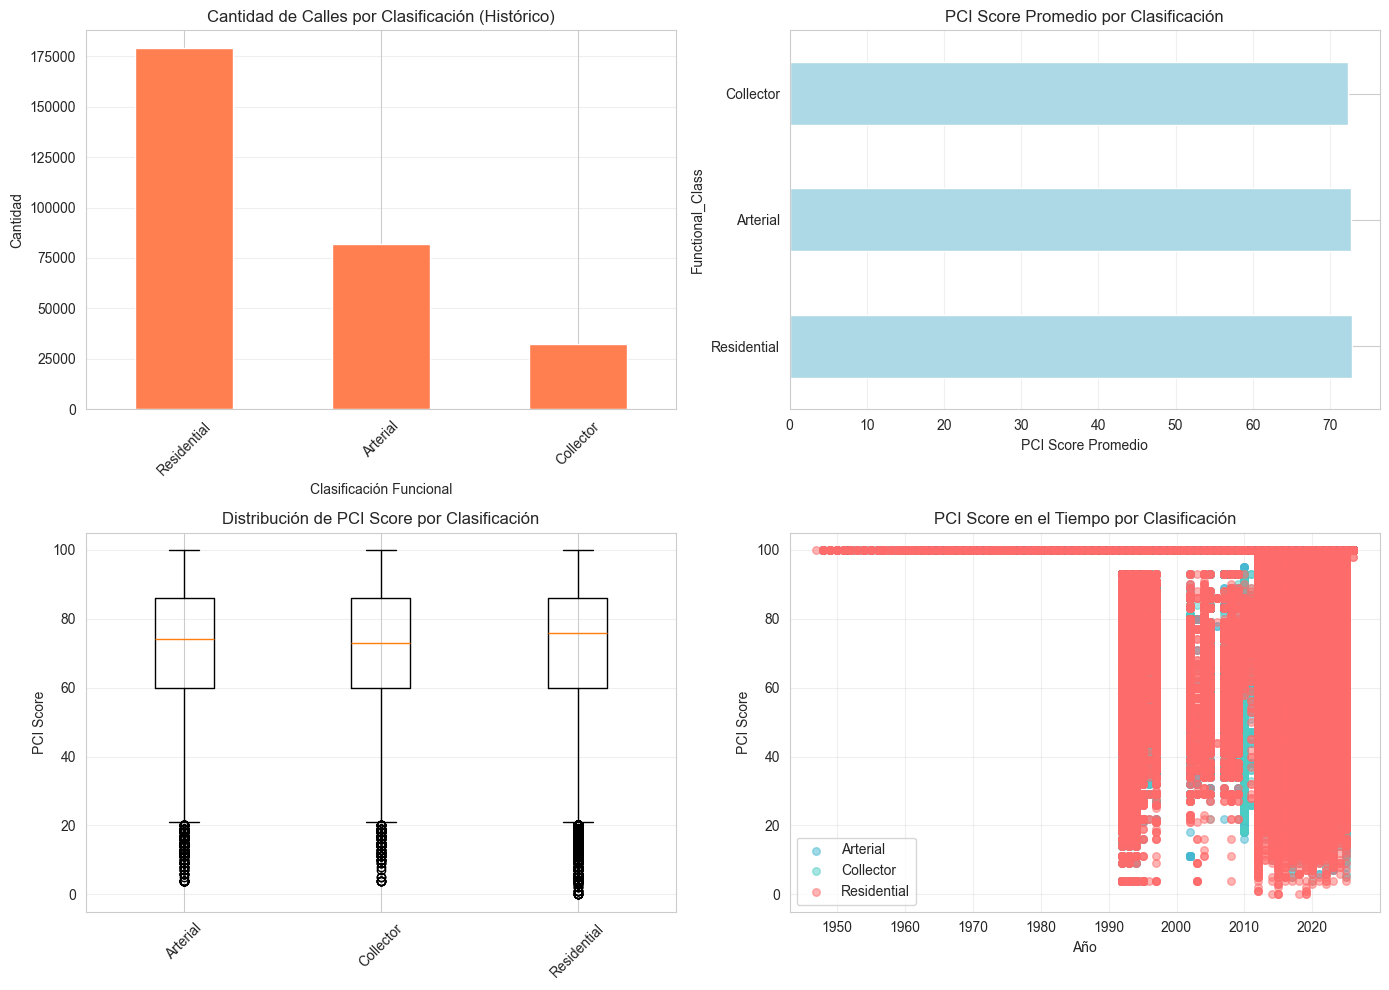

✓ Gráficos de clasificación generados


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cantidad por clasificación
func_class_counts = df_with_class['Functional_Class'].value_counts()
func_class_counts.plot(kind='bar', ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Cantidad de Calles por Clasificación (Histórico)')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].set_xlabel('Clasificación Funcional')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# PCI promedio por clasificación
avg_pci_by_class = df_with_class.groupby('Functional_Class')['PCI_Score'].mean().sort_values(ascending=False)
avg_pci_by_class.plot(kind='barh', ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('PCI Score Promedio por Clasificación')
axes[0, 1].set_xlabel('PCI Score Promedio')
axes[0, 1].grid(axis='x', alpha=0.3)

# Box plot por clasificación
func_classes = sorted(df_with_class['Functional_Class'].unique())
data_by_class = [df_with_class[df_with_class['Functional_Class'] == fc]['PCI_Score'].values for fc in func_classes]
axes[1, 0].boxplot(data_by_class, labels=func_classes)
axes[1, 0].set_title('Distribución de PCI Score por Clasificación')
axes[1, 0].set_ylabel('PCI Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter plot por clasificación (con fechas válidas)
df_with_class_dates = df_with_class[df_with_class['Year'].notna()]
colors_class = {'Residential': '#FF6B6B', 'Collector': '#4ECDC4', 'Arterial': '#45B7D1'}
for func_class in sorted(df_with_class_dates['Functional_Class'].unique()):
    subset = df_with_class_dates[df_with_class_dates['Functional_Class'] == func_class]
    axes[1, 1].scatter(subset['Year'], subset['PCI_Score'], 
                      label=func_class, alpha=0.5, s=30,
                      color=colors_class.get(func_class, 'gray'))
axes[1, 1].set_title('PCI Score en el Tiempo por Clasificación')
axes[1, 1].set_ylabel('PCI Score')
axes[1, 1].set_xlabel('Año')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Gráficos de clasificación generados')

## 15. Análisis de Coordenadas y Ubicación

In [38]:
print('\n' + '='*80)
print('ANÁLISIS DE COORDENADAS Y UBICACIÓN (Histórico)')
print('='*80)

# Coordenadas X
print('\nCOORDENADAS X (UTM):')
print('-' * 60)
print(f'Mínimo:           {df_hist["X"].min():,.2f}')
print(f'Máximo:           {df_hist["X"].max():,.2f}')
print(f'Media:            {df_hist["X"].mean():,.2f}')
print(f'Rango:            {df_hist["X"].max() - df_hist["X"].min():,.2f}')
print(f'Desv. Estándar:   {df_hist["X"].std():,.2f}')

# Coordenadas Y
print('\nCOORDENADAS Y (UTM):')
print('-' * 60)
print(f'Mínimo:           {df_hist["Y"].min():,.2f}')
print(f'Máximo:           {df_hist["Y"].max():,.2f}')
print(f'Media:            {df_hist["Y"].mean():,.2f}')
print(f'Rango:            {df_hist["Y"].max() - df_hist["Y"].min():,.2f}')
print(f'Desv. Estándar:   {df_hist["Y"].std():,.2f}')

# Latitud
print('\nLATITUD (WGS84):')
print('-' * 60)
print(f'Mínimo:           {df_hist["Latitude"].min():.6f}')
print(f'Máximo:           {df_hist["Latitude"].max():.6f}')
print(f'Media:            {df_hist["Latitude"].mean():.6f}')
print(f'Rango:            {df_hist["Latitude"].max() - df_hist["Latitude"].min():.6f}')

# Longitud
print('\nLONGITUD (WGS84):')
print('-' * 60)
print(f'Mínimo:           {df_hist["Longitude"].min():.6f}')
print(f'Máximo:           {df_hist["Longitude"].max():.6f}')
print(f'Media:            {df_hist["Longitude"].mean():.6f}')
print(f'Rango:            {df_hist["Longitude"].max() - df_hist["Longitude"].min():.6f}')


ANÁLISIS DE COORDENADAS Y UBICACIÓN (Histórico)

COORDENADAS X (UTM):
------------------------------------------------------------
Mínimo:           5,979,771.01
Máximo:           6,022,486.29
Media:            6,001,705.80
Rango:            42,715.27
Desv. Estándar:   9,086.90

COORDENADAS Y (UTM):
------------------------------------------------------------
Mínimo:           2,086,001.54
Máximo:           2,127,218.54
Media:            2,103,780.15
Rango:            41,217.00
Desv. Estándar:   9,665.82

LATITUD (WGS84):
------------------------------------------------------------
Mínimo:           37.707903
Máximo:           37.822087
Media:            37.756671
Rango:            0.114185

LONGITUD (WGS84):
------------------------------------------------------------
Mínimo:           -122.513581
Máximo:           -122.366569
Media:            -122.437097
Rango:            0.147012


## 16. Mapa Geográfico Histórico

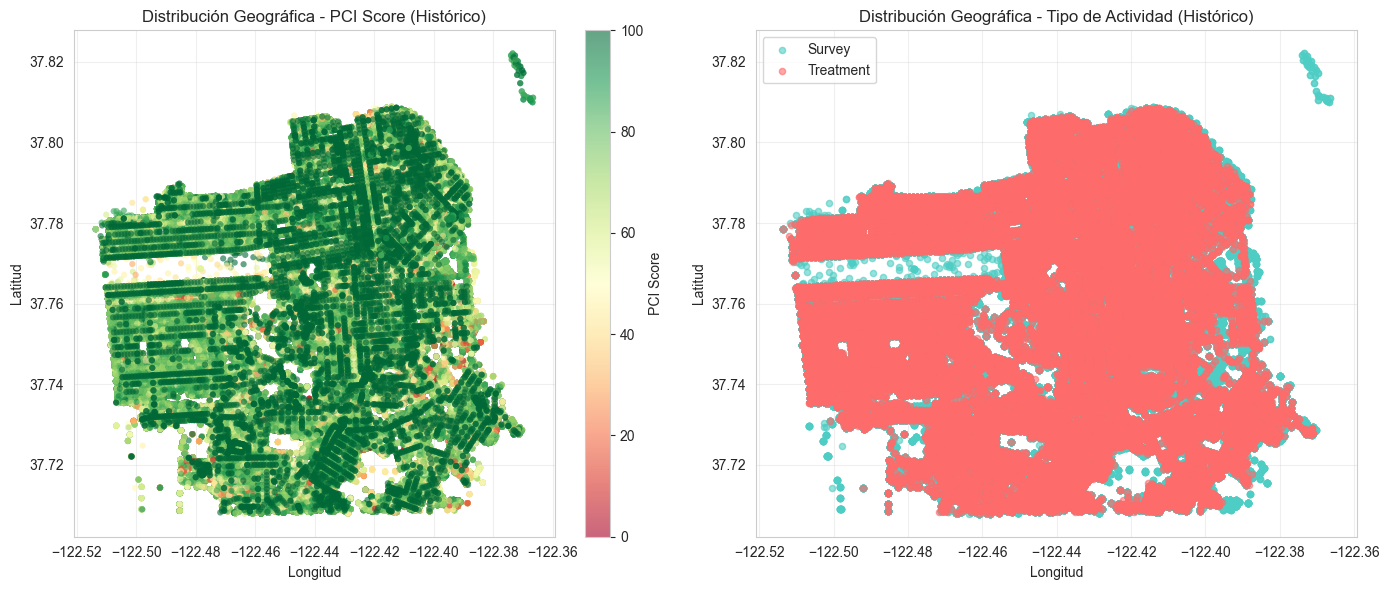

✓ Mapas geográficos generados


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot con colores por PCI
scatter = axes[0].scatter(df_hist['Longitude'], df_hist['Latitude'], 
                          c=df_hist['PCI_Score'], cmap='RdYlGn',
                          alpha=0.6, s=20, edgecolors='none')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].set_title('Distribución Geográfica - PCI Score (Histórico)')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('PCI Score')
axes[0].grid(True, alpha=0.3)

# Scatter plot con colores por tipo de tratamiento
colors_treatment = {'Treatment': '#FF6B6B', 'Survey': '#4ECDC4'}
for treatment_type in df_hist['Treatment_or_Survey'].unique():
    mask = df_hist['Treatment_or_Survey'] == treatment_type
    axes[1].scatter(df_hist[mask]['Longitude'], df_hist[mask]['Latitude'],
                   label=treatment_type, alpha=0.6, s=20,
                   color=colors_treatment.get(treatment_type, 'gray'))
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].set_title('Distribución Geográfica - Tipo de Actividad (Histórico)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Mapas geográficos generados')

## 17. Detección de Duplicados

In [40]:
print('\n' + '='*80)
print('ANÁLISIS DE DUPLICADOS (Histórico)')
print('='*80)

# Duplicados en CNN
duplicated_cnn = df_hist['CNN'].duplicated().sum()
print(f'\nDuplicados en CNN (por ID único): {duplicated_cnn}')

if duplicated_cnn > 0:
    duplicate_ids = df_hist[df_hist['CNN'].duplicated(keep=False)].sort_values('CNN')
    print(f'\nObservación: Esto es normal en el dataset histórico')
    print(f'ya que la misma calle puede tener múltiples registros en diferentes años.')
    print(f'\nPrimeros CNNs con múltiples registros:')
    cnn_counts = df_hist['CNN'].value_counts()
    cnn_multiple = cnn_counts[cnn_counts > 1]
    print(f'Total de CNNs únicos: {df_hist["CNN"].nunique():,}')
    print(f'CNNs con múltiples registros: {len(cnn_multiple):,}')
    print(f'Número máximo de registros para un CNN: {cnn_counts.max()}')

# Filas completamente duplicadas
complete_duplicates = df_hist.duplicated().sum()
print(f'\nFilas completamente duplicadas (idénticas): {complete_duplicates}')


ANÁLISIS DE DUPLICADOS (Histórico)

Duplicados en CNN (por ID único): 288784

Observación: Esto es normal en el dataset histórico
ya que la misma calle puede tener múltiples registros en diferentes años.

Primeros CNNs con múltiples registros:
Total de CNNs únicos: 18,349
CNNs con múltiples registros: 16,198
Número máximo de registros para un CNN: 31

Filas completamente duplicadas (idénticas): 0


## 18. Evolución de Calles en el Tiempo

In [41]:
# Análisis: calcular promedio de PCI por CNN a través del tiempo
print('\n' + '='*80)
print('ANÁLISIS DE EVOLUCIÓN - CALLES A TRAVÉS DEL TIEMPO')
print('='*80)

# Filtrar datos con fechas válidas
df_hist_dates = df_hist[df_hist['Year'].notna()].copy()

# Calles con más registros históricos
cnn_counts = df_hist_dates['CNN'].value_counts()
print(f'\nTop 10 calles con más registros históricos:')
print('-' * 60)

for idx, (cnn, count) in enumerate(cnn_counts.head(10).items(), 1):
    street_name = df_hist_dates[df_hist_dates['CNN'] == cnn]['Street_Name'].iloc[0]
    years = sorted(df_hist_dates[df_hist_dates['CNN'] == cnn]['Year'].unique())
    print(f'{idx:2d}. CNN {cnn}: {street_name:25s} - {count} registros (años: {min(years)}-{max(years)})')

# Ejemplo: evolución de una calle específica
print('\n' + '-' * 60)
example_cnn = cnn_counts.index[0]
example_street = df_hist_dates[df_hist_dates['CNN'] == example_cnn]['Street_Name'].iloc[0]
print(f'\nEjemplo: Evolución de "{example_street}" (CNN: {example_cnn})')
print('-' * 60)

evolution = df_hist_dates[df_hist_dates['CNN'] == example_cnn][['Year', 'PCI_Score', 'Treatment_or_Survey']].sort_values('Year')
print(evolution.to_string(index=False))


ANÁLISIS DE EVOLUCIÓN - CALLES A TRAVÉS DEL TIEMPO

Top 10 calles con más registros históricos:
------------------------------------------------------------
 1. CNN 867000: 18th St                   - 31 registros (años: 1987.0-2025.0)
 2. CNN 1458000: 25th St                   - 31 registros (años: 1970.0-2025.0)
 3. CNN 1644000: 30th Ave                  - 30 registros (años: 1971.0-2025.0)
 4. CNN 959000: 19th St                   - 30 registros (años: 1961.0-2025.0)
 5. CNN 9602000: Nibbi Ct                  - 30 registros (años: 1986.0-2025.0)
 6. CNN 2512000: Ashbury St                - 30 registros (años: 1983.0-2025.0)
 7. CNN 1642000: 30th Ave                  - 30 registros (años: 1959.0-2025.0)
 8. CNN 11688000: SCOTT ST                  - 30 registros (años: 1965.0-2025.0)
 9. CNN 10183000: Page St                   - 29 registros (años: 1987.0-2025.0)
10. CNN 160000: 03rd Ave                  - 29 registros (años: 1971.0-2025.0)

------------------------------------------

## 19. Correlaciones Numéricas


MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS (Histórico)
           PCI_Score      X      Y  Latitude  Longitude   Year
PCI_Score      1.000 -0.043 -0.003    -0.004     -0.043  0.012
X             -0.043  1.000  0.107     0.126      1.000 -0.001
Y             -0.003  0.107  1.000     1.000      0.085 -0.014
Latitude      -0.004  0.126  1.000     1.000      0.104 -0.014
Longitude     -0.043  1.000  0.085     0.104      1.000 -0.001
Year           0.012 -0.001 -0.014    -0.014     -0.001  1.000


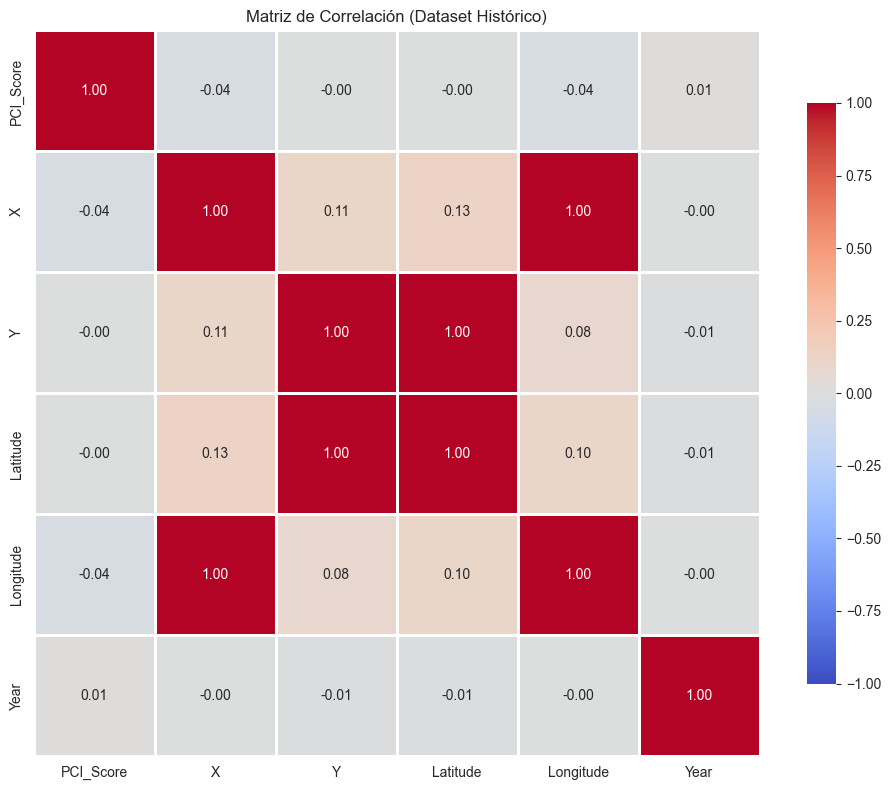


✓ Gráfico de correlación generado


In [42]:
# Seleccionar columnas numéricas
numeric_cols = df_hist[['PCI_Score', 'X', 'Y', 'Latitude', 'Longitude', 'Year']].copy()

# Calcular correlación
correlation_matrix = numeric_cols.corr()

print('\n' + '='*80)
print('MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS (Histórico)')
print('='*80)
print(correlation_matrix.round(3))

# Gráfico de correlación
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            fmt='.2f', vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación (Dataset Histórico)')
plt.tight_layout()
plt.show()

print('\n✓ Gráfico de correlación generado')

## 20. Primeras Filas y Últimas Filas

In [43]:
print('\n' + '='*80)
print('PRIMERAS 10 FILAS DEL DATASET HISTÓRICO')
print('='*80)
print(df_hist.head(10)[['CNN', 'Street_Name', 'PCI_Score', 'PCI_Change_Date', 'Year', 'Treatment_or_Survey']].to_string())

print('\n' + '='*80)
print('ÚLTIMAS 10 FILAS DEL DATASET HISTÓRICO')
print('='*80)
print(df_hist.tail(10)[['CNN', 'Street_Name', 'PCI_Score', 'PCI_Change_Date', 'Year', 'Treatment_or_Survey']].to_string())


PRIMERAS 10 FILAS DEL DATASET HISTÓRICO
        CNN   Street_Name  PCI_Score     PCI_Change_Date    Year Treatment_or_Survey
0  11007000       Rice St         80 2012-03-13 13:35:18  2012.0              Survey
1  11760000    Seneca Ave         62 2016-06-07 07:45:15  2016.0           Treatment
2   8785000    MARTHA AVE        100 2008-10-29 13:59:26  2008.0              Survey
3   7482000   Jennings St         76 2016-10-03 12:56:35  2016.0              Survey
4   7037000     HOWARD ST         46 1996-08-03 00:00:00  1996.0              Survey
5   6995101  Holloway Ave         50 2019-10-01 16:14:04  2019.0              Survey
6   6885001    HERMANN ST         82 1993-01-01 00:00:00  1993.0              Survey
7   8778000     MARNE AVE         60 2008-10-29 13:59:26  2008.0              Survey
8  13744000       Yale St         48 2015-11-24 19:54:29  2015.0              Survey
9  12603000  Thornton Ave         91 2023-10-07 17:18:01  2023.0              Survey

ÚLTIMAS 10 FILAS DEL DA